In [2]:
%pip install qiskit==1.2.4
%pip install qiskit-aer==0.15.1
%pip install pylatexenc==2.10

from qiskit import QuantumCircuit
from qiskit.converters import circuit_to_gate
from qiskit.visualization import array_to_latex
from qiskit.quantum_info import Operator
from qiskit.quantum_info import Statevector
from qiskit import transpile
from qiskit.providers.basic_provider import BasicSimulator
from qiskit.visualization import plot_histogram

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.8/4.8 MB 46.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 63.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.5/54.5 kB 3.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.6/49.6 MB 14.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.3/12.3 MB 39.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 162.6/162.6 kB 4.1 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for pylatexenc: filename=pylatexenc-2.10-py3-none-any.whl size=136817 sha256=18989ed6221e56a2e736a33e0aaab8abc6fc0c60e76c030fa4d2688a32e3a5bd
  Stored in directory: /root/.cache/pip/wheels/06/3e/78/fa1588c1ae991bbfd814af2bcac6cef7a178beee1939180d46
Successfully built pylatexenc


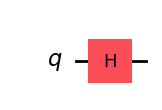

In [3]:

# Create a circuit with one qubit
circuit = QuantumCircuit(1)

# Add a Hadamard (H) gate on qubit 0, to create a superposition
circuit.h(0)

# Draw the circuit diagram. Delete "mpl" to get a text diagram.
circuit.draw("mpl")

In [4]:
# Now simulate the circuit by calculating the effect on state vectors.
# Set the initial state of the simulator to |0>
# The state vector has two coefficients, both 0
state = Statevector.from_int(0, 2)

# Apply the circuit to the state
state = state.evolve(circuit)

# Display using latex. This requires the pylatexenc module.
# Omit "latex" to get a numerical (not algebraic) view of the state vector.
state.draw("latex")

<IPython.core.display.Latex object>

In [5]:
# A different way of dislaying the state, again using latex
from qiskit.visualization import array_to_latex

array_to_latex(state)

<IPython.core.display.Latex object>

In [6]:
# The whole circuit is a unitary operator, which we can display.

U = Operator(circuit)
array_to_latex(U)

<IPython.core.display.Latex object>

In [7]:
# Or less beautifully:
U.data
# The format is a little bit odd. 0.j means the imaginary part is 0
# 0 is being displayed with a decimal point but no trailing 0
# j is used for the square root of -1, instead of i

array([[ 0.70710678+0.j,  0.70710678+0.j],
       [ 0.70710678+0.j, -0.70710678+0.j]])

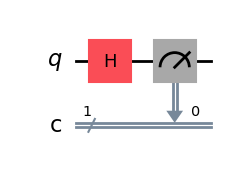

In [8]:
# Now reconstruct the circuit and add a measurement
# The second parameter of QuantumCircuit is the number of classical bits
circuit = QuantumCircuit(1,1)
circuit.h(0)

# The first list is the qubits to measure,
# the second list is the classical bits where the results go
circuit.measure([0],[0])
circuit.draw("mpl")

In [9]:
# We will need to transpile the circuit into QASM instructions for the back end

# Use BasicSimulator
backend = BasicSimulator()

# Compile / transpile
qc_compiled = transpile(circuit, backend)

# Run the circuit on the simulator.
# We've set the number of repeats of the circuit
# to be 1024, which is the default.
# The qubits start in state |0>
job_sim = backend.run(qc_compiled, shots=1024)

# Grab the results from the job (this doesn't produce any output).
result_sim = job_sim.result()

In [10]:
# The simplest way to see the results of the simulation
counts = result_sim.get_counts(qc_compiled)
print(counts)

# The results are not exactly half 0 and half 1, but should be close.
# There will be different results each time the previous cell is run.

{'0': 494, '1': 530}


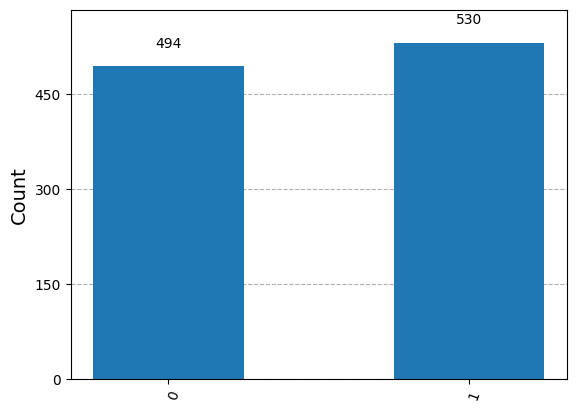

In [11]:
# We can also produce a graph

plot_histogram(counts)

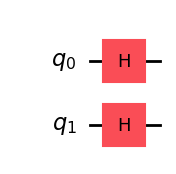

In [12]:
# Now let's move on to two qubits.
# Apply H to both qubits and see what we get.

circuit = QuantumCircuit(2)
circuit.h(0)
circuit.h(1)

circuit.draw("mpl")

In [13]:
state = Statevector.from_int(0, 4) # 4 is the number of basis states on 2 qubits
state = state.evolve(circuit)
state.draw("latex")

<IPython.core.display.Latex object>

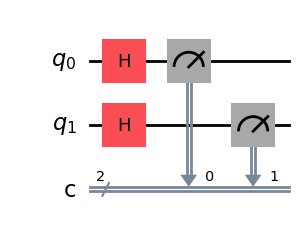

In [14]:
# Now measurement. This time we construct the measurement part
# of the circuit separately and then combine it with the first circuit.

# A new circuit with 2 qubits and 2 classical bits
meas = QuantumCircuit(2, 2)

# Map the quantum measurement to the classical bits
meas.measure(range(2), range(2))

# The Qiskit circuit object supports composition.
# Here the meas has to be first and front=True (putting it before)
# as compose must put a smaller circuit into a larger one.
qc = meas.compose(circuit, range(2), front=True)

qc.draw("mpl")

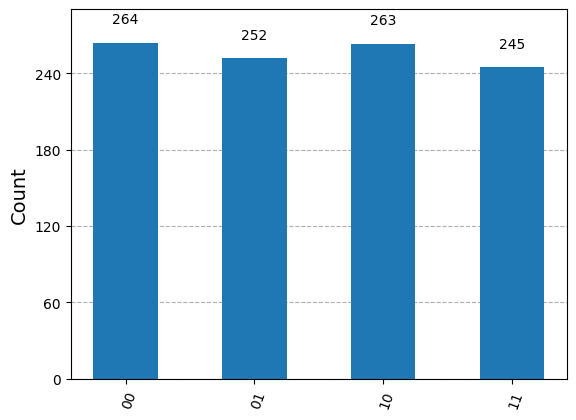

In [15]:
# Simulate again, using the same back end
qc_compiled = transpile(qc, backend)
job_sim = backend.run(qc_compiled, shots=1024)
result_sim = job_sim.result()
counts = result_sim.get_counts(qc_compiled)
plot_histogram(counts)

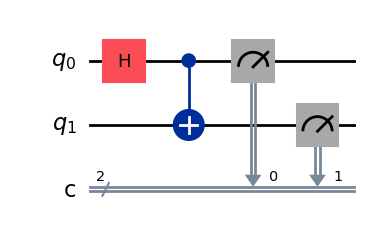

In [16]:
# Now for some entanglement.
# Construct a Bell state and measure both qubits to see that
# both measurements give the same result.

circuit = QuantumCircuit(2,2)
circuit.h(0)
circuit.cx(0,1) # cx means CNOT because it's a controlled version of x (negation)
circuit.measure(range(2),range(2))
circuit.draw("mpl")

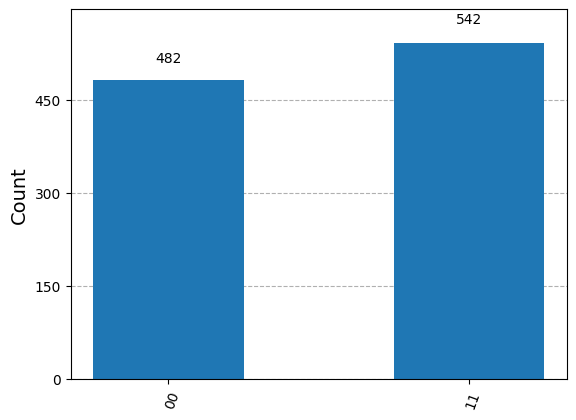

In [17]:
qc_compiled = transpile(circuit, backend)
job_sim = backend.run(qc_compiled, shots=1024)
result_sim = job_sim.result()
counts = result_sim.get_counts(qc_compiled)
plot_histogram(counts)

Statevector for (|00> - |11>) / sqrt(2):


<IPython.core.display.Latex object>

Statevector for (|01> + |10>) / sqrt(2):


<IPython.core.display.Latex object>

Statevector for (|01> - |10>) / sqrt(2):


<IPython.core.display.Latex object>

Result for (|00> - |11>)/sqrt(2): {'00': 510, '11': 514}


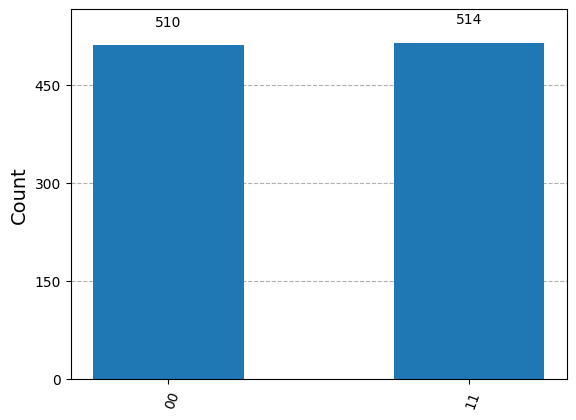

Result for (|01> + |10>)/sqrt(2): {'01': 521, '10': 503}


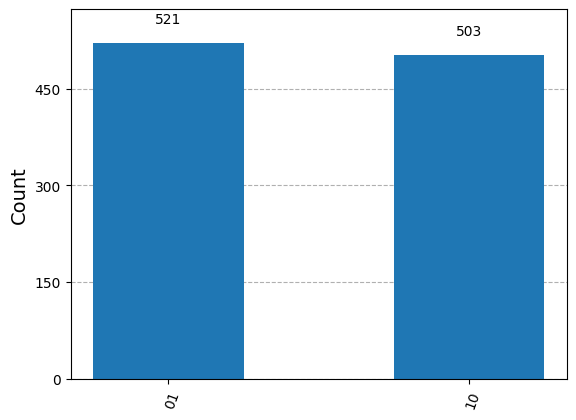

Result for (|01> - |10>)/sqrt(2): {'10': 516, '01': 508}


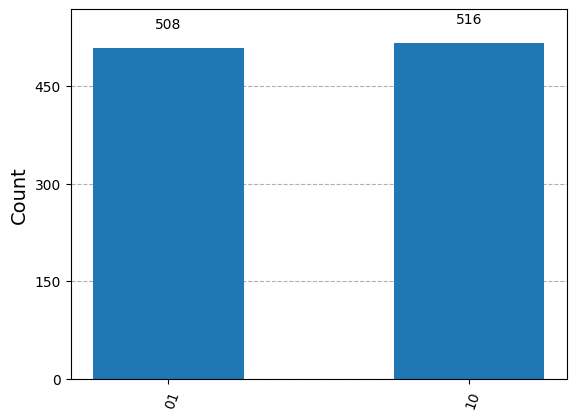

In [19]:
# EXERCISE

# Make a copy here of the circuit that creates the Bell state 1/sqrt(2) ( |00> + |11> ).
exercise_circuit = QuantumCircuit(2,2)
exercise_circuit.h(0)
exercise_circuit.cx(0,1)

# Modify it to create the other Bell states: 1/sqrt(2) ( |00> - |11> )
# You will need to use X and Z gates. Check that your circuit is correct by displaying the state vector in each case.
bell_circuit_00_minus = exercise_circuit.copy()
bell_circuit_00_minus.z(1) # Applu Z gate to the second qubit

bell_circuit_00_minus_state = Statevector.from_instruction(bell_circuit_00_minus)
print("Statevector for (|00> - |11>) / sqrt(2):")
display(bell_circuit_00_minus_state.draw("latex"))

# Modify it to create the other Bell states: 1/sqrt(2) ( |01> + |10> )
# You will need to use X and Z gates. Check that your circuit is correct by displaying the state vector in each case.
bell_circuit_01_plus = exercise_circuit.copy()
bell_circuit_01_plus.x(1)

bell_circuit_01_plus_state = Statevector.from_instruction(bell_circuit_01_plus)
print("Statevector for (|01> + |10>) / sqrt(2):")
display(bell_circuit_01_plus_state.draw("latex"))

# Modify it to create the other Bell states: 1sqrt(2) ( |01> - |10> )
# You will need to use X and Z gates. Check that your circuit is correct by displaying the state vector in each case.
bell_circuit_01_minus = exercise_circuit.copy()
bell_circuit_01_minus.z(0)
bell_circuit_01_minus.x(1)

bell_circuit_01_minus_state = Statevector.from_instruction(bell_circuit_01_minus)
print("Statevector for (|01> - |10>) / sqrt(2):")
display(bell_circuit_01_minus_state.draw("latex"))

# For each of the Bell states, repeat the simulation with measurements and check that the results are as expected.
bell_circuit_00_minus.measure(range(2),range(2))
bell_circuit_01_plus.measure(range(2),range(2))
bell_circuit_01_minus.measure(range(2), range(2))

bell_dict = {
    "(|00> - |11>)/sqrt(2)": bell_circuit_00_minus,
    "(|01> + |10>)/sqrt(2)": bell_circuit_01_plus,
    "(|01> - |10>)/sqrt(2)": bell_circuit_01_minus
}

for name, qc in bell_dict.items():
  qc_compile = transpile(qc, backend)
  job = backend.run(qc_compile, shots=1024)
  counts = job.result().get_counts()

  print(f"Result for {name}: {counts}")
  display(plot_histogram(counts))

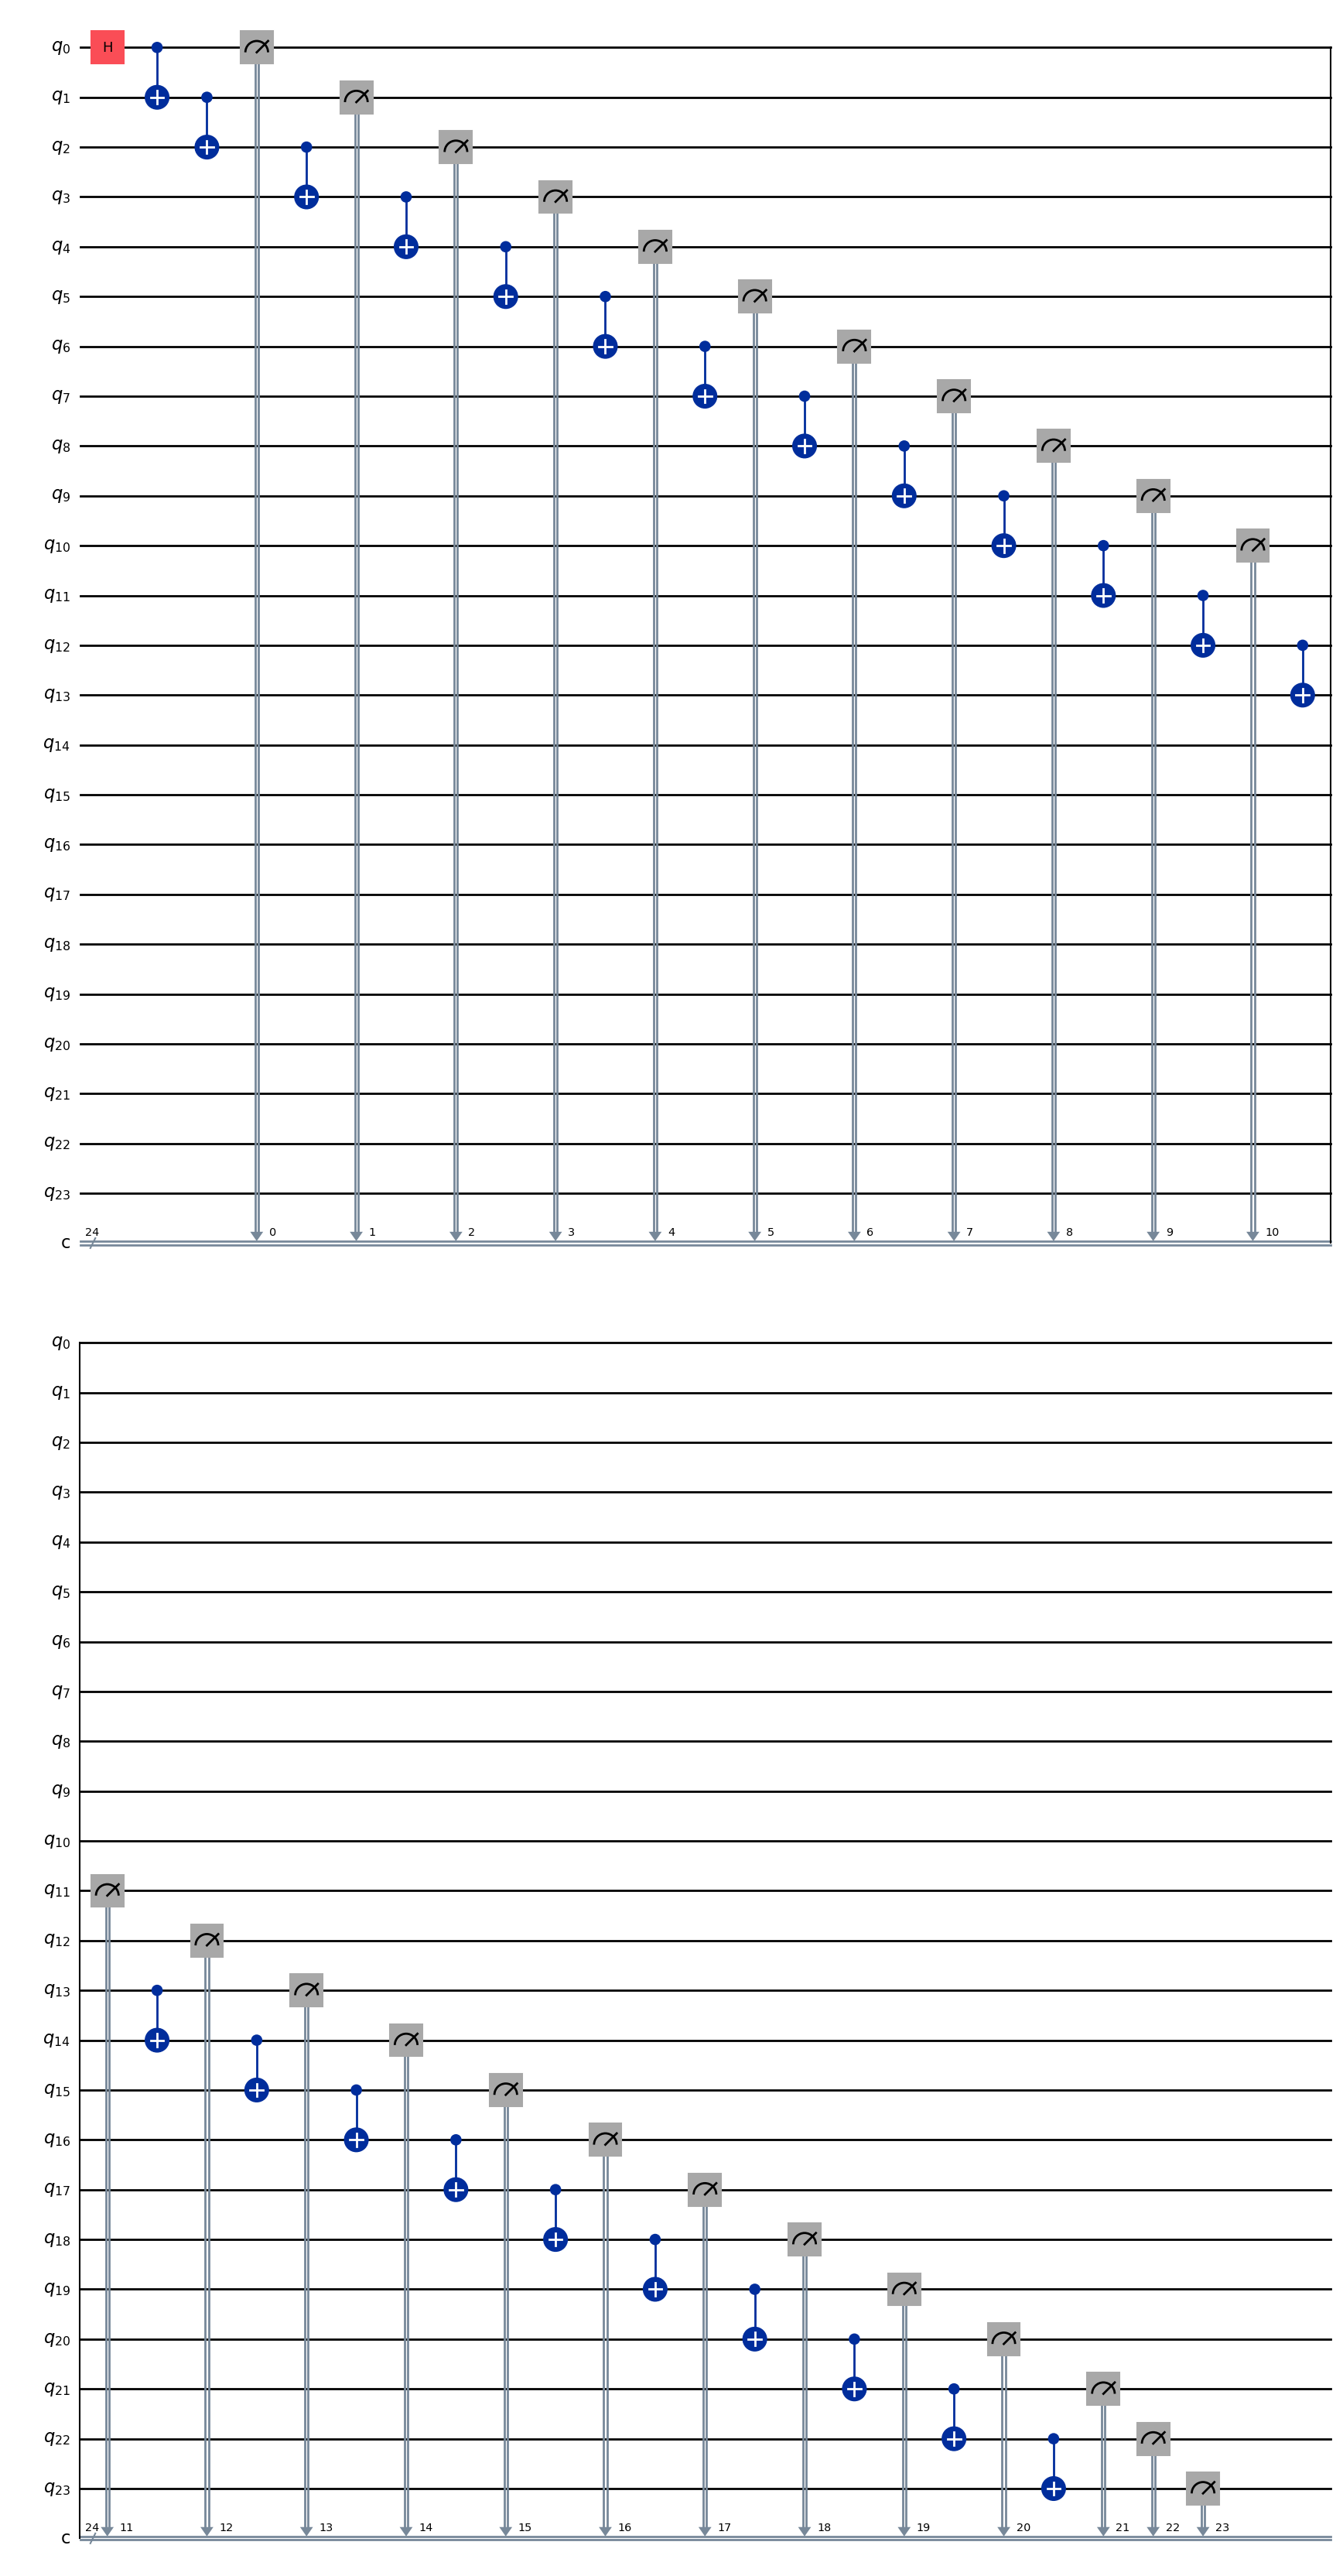

GHZ-24 Results: {'111111111111111111111111': 516, '000000000000000000000000': 508}


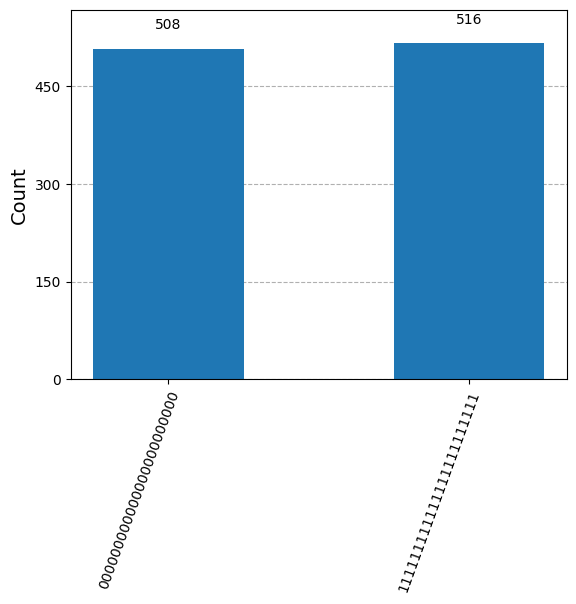

In [24]:
# EXERCISE

# The GHZ state on any number of qubits has the form  1/sqrt(2) ( |00...0> + |11...1> )
# The Bell state 1/sqrt(2) ( |00> + |11> ) is the case for two qubits.

# Write code to construct a circuit that produces a GHZ state for any given number of qubits.
def create_and_simulate_ghz_circuit(n):
  ghz_circuit = QuantumCircuit(n,n)
  ghz_circuit.h(0)

  # Apply CNOT gate to the qubits x n-1
  for i in range(n-1):
    ghz_circuit.cx(i, i + 1)

  # Measure
  ghz_circuit.measure(range(n), range(n))

  # Draw Circuit
  display(ghz_circuit.draw("mpl"))

  # Simulation
  qc_compiled = transpile(ghz_circuit, backend)
  job = backend.run(qc_compiled, shots=1024)
  counts = job.result().get_counts()

  print(f"GHZ-{n} Results: {counts}")
  display(plot_histogram(counts))

# Try simulating the circuit, with measurements. How many qubits can the simulator handle in a reasonable time?
# Ans: 24 Qubits for basic_simulator. 25 qubits runs into an error. BasicProviderError: 'Number of qubits 25 is greater than maxium (24) for "basic_simulator".'
create_and_simulate_ghz_circuit(24)